# **Dimension reduction lab**

Jesse van der Ende and Mohamed Amine Ziddi

## **1.Introduction**

In this lab, we study the **matrix completion problem** for movie rating prediction.
Users rate only a small number of movies, which leads to a very sparse data matrix.
The goal is to predict the missing ratings from the observed ones.

We assume that the rating matrix has a **low-rank structure**, meaning that user
preferences can be explained by a small number of latent factors.
Based on this assumption, we implement and compare three matrix completion algorithms:
**Singular Value Projection (SVP)**, **Singular Value Thresholding (SVT)**, and
**ADMiRA**.

The algorithms are evaluated using the MovieLens dataset, and their performance is
compared in terms of reconstruction error and computation time.

## **2. Problem Formulation**

Formally, we represent the movie ratings as a matrix $Y \in \mathbb{R}^{n \times m}$, where $n$ is the number of users and $m$ is the number of movies. Each entry $Y_{ij}$ corresponds to the rating given by user $i$ to movie $j$.

In practice, only a subset of ratings is observed.
We denote by $S$ the set of observed (user, movie) pairs.
The training data is stored in the matrix $Y_S$, defined as
$$
(Y_S)_{ij} =
\begin{cases}
Y_{ij} & \text{if } (i,j) \in S, \\
0 & \text{otherwise}.
\end{cases}
$$

To recover the missing entries, we assume that the true rating matrix has **low rank**. The matrix completion problem is then formulated as
$$
\hat X_r = \arg\min_{\mathrm{rank}(X)\le r} \| X_S - Y_S \|_2^2,
$$
where $X_S$ denotes the restriction of $X$ to the observed entries.

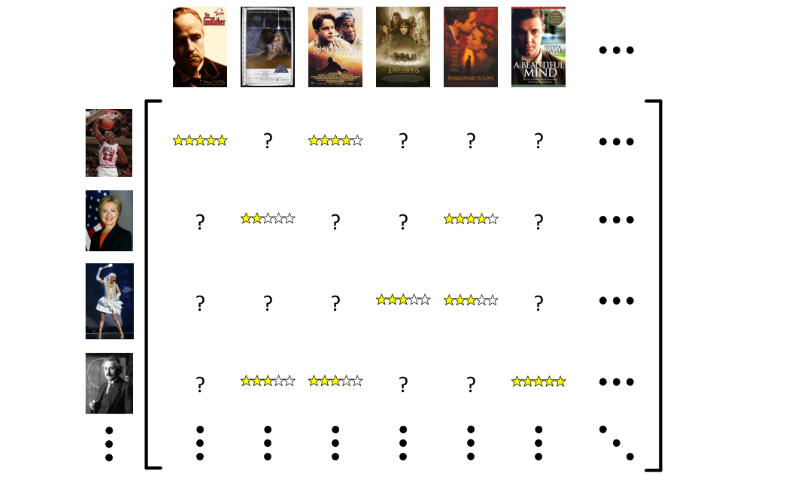


## **3. Dataset**

We will use the MovieLens dataset, available at the following url:
https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

In [18]:
import pandas as pd
data = pd.read_csv('ml-latest-small/ratings.csv')
data.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


The MovieLens dataset contains movie ratings given by users. Each user rates only a small number of movies, which results in a highly sparse dataset, as illustrated by the measures below.

In [19]:
#Matrix density
n_users = data.userId.unique().shape[0]
n_movies = data.movieId.unique().shape[0]

density = len(data) / (n_users * n_movies)
sparsity = 1 - density

print(f"Matrix density: {density:.6f}")
print(f"Matrix sparsity: {sparsity:.6f}")


Matrix density: 0.017000
Matrix sparsity: 0.983000


To efficiently store and manipulate this data, we use sparse matrix representations from the `scipy` library. There are two main formats:

**COO (Coordinate format)**:
- Stores three arrays: row indices, column indices, and values
- Simple structure: just a list of (row, col, value) triplets
- **Advantages**: Very efficient for matrix construction, especially when adding entries incrementally
- **Disadvantages**: Slow for arithmetic operations and element access. Each lookup requires searching through arrays

**CSR (Compressed Sparse Row)**:
- Compresses row information using row pointers for efficient row-wise operations
- More complex internal structure but optimized for computation
- **Advantages**: Fast arithmetic operations, efficient fancy indexing with integer arrays, good memory locality
- **Disadvantages**: More expensive to construct or modify

**Our choice: CSR**

We use **CSR** because our matrix completion algorithms require:

1. Repeated fancy indexing: `X[rows, cols]` to access observed entries
2. Element-wise operations: `vals - X[rows, cols]` on indexed entries  
3. All three algorithms (SVP, SVT, ADMiRA) follow this pattern throughout their iterations

Since we construct the matrix once from existing data and then perform many computational operations, CSR is optimal.

In [20]:
from scipy.sparse import csr_matrix

# Step 1: Map user and movie IDs to consecutive indices
# The raw data has non-consecutive IDs (e.g., user 1, 5, 17, ...)
# We need consecutive indices (0, 1, 2, ...) for matrix construction
user_ids = data["userId"].unique()
movie_ids = data["movieId"].unique()

user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: j for j, m in enumerate(movie_ids)}

# Step 2: Create coordinate arrays
# rows[k] = row index of k-th rating
# cols[k] = column index of k-th rating  
# vals[k] = value of k-th rating
rows = data["userId"].map(user_map).to_numpy()
cols = data["movieId"].map(movie_map).to_numpy()
vals = data["rating"].to_numpy().astype(float)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(n_users, n_movies, len(vals))

# Step 3: Construct CSR matrix from triplets
# Syntax: csr_matrix((data, (row_indices, col_indices)), shape=(nrows, ncols))
# This creates a matrix where Y_S[rows[k], cols[k]] = vals[k] for all k
Y_S = csr_matrix((vals, (rows, cols)), shape=(n_users, n_movies))
print(Y_S.shape)

# Test: verify the construction worked correctly
k = 0  # test the first rating
i, j, r = rows[k], cols[k], vals[k]

print("Example rating from data:", r)
print("Same rating in Y_S:", Y_S[i, j])

610 9724 100836
(610, 9724)
Example rating from data: 4.0
Same rating in Y_S: 4.0


## **4. Preliminary questions**

---

### *(i) How is this problem related to the course? To which of the sparse linear regression algorithms (matching pursuit, iterative hard thresholding, convex relaxation) can you compare each of the three completion algorithms?*


Before analyzing which algorithm corresponds to which completion algorithm, we evaluate the equivalences between sparse linear regression and matrix completion.

We first recall the sparse regression problem:

$$
\min_{\beta \in \mathbb{R}^d} \|y - X\beta\|_2^2 
\quad \text{s.t.} \quad \|\beta\|_0 \le s,
$$

where $\|\beta\|_0$ denotes the number of nonzero entries of $\beta$. A sparse vector can be written as a combination of only a few canonical basis vectors:

$$
\beta = \sum_{j \in \mathcal{S}} \beta_j e_j,
\qquad |\mathcal{S}| \le s.
$$

Thus, sparsity means that the solution lives in a low-dimensional subspace spanned by a small number of basis directions. Matrix completion is the **low-rank analogue** of this idea. We solve

$$
\min_{X \in \mathbb{R}^{n \times m}} 
\|X^S - Y^S\|_F^2
\quad \text{s.t.} \quad 
\operatorname{rank}(X) \le r.
$$

To understand the analogy, consider the Singular Value Decomposition (SVD):

$$
X = U \Sigma V^\top
= \sum_{k=1}^{\min(n,m)} \sigma_k u_k v_k^\top.
$$

Each term $u_k v_k^\top$ is a rank-one matrix. Therefore, any matrix is a sum of rank-one components. If $\operatorname{rank}(X) \le r$, then only the first $r$ singular values are nonzero:

$$
X = \sum_{k=1}^{r} \sigma_k u_k v_k^\top.
$$

This is directly analogous to the sparse vector decomposition:

$$
\beta = \sum_{j \in \mathcal{S}} \beta_j e_j.
$$

In both cases:

- A sparse vector uses only a few basis directions.
- A low-rank matrix uses only a few rank-one components.

We can therefore summarize the correspondence:

- Sparsity constraint $\|\beta\|_0 \le s$
  $\Longleftrightarrow$
  Rank constraint $\operatorname{rank}(X) \le r$

- Canonical basis vectors $e_j$
  $\Longleftrightarrow$
  Rank-one matrices $u_k v_k^\top$

- Keeping the largest coefficients
  $\Longleftrightarrow$
  Keeping the largest singular values (truncated SVD)

Matrix completion is thus the natural matrix generalization of sparse linear regression, and we can now compare the sparse linear regression algorithms with the matrix completion ones.



#### **Matching Pursuit $\Longleftrightarrow$  ADMiRA**

In sparse regression, Matching Pursuit builds the solution iteratively by selecting one direction at a time. Using the definition from the course, we initialize $\beta_0=0$ have at iteration $t$:

1. Compute the residual
   $$
   r_t = y - X\beta_t.
   $$

2. For each $j$, compute the residual obtained by adding $j$ to $\operatorname{supp}(\beta_t)$:
   $$
   r_t^j = r_t - \langle r_t, X_j \rangle X_j.
   $$

3. Select the index that minimizes the residual norm:
   $$
   j_t = \arg\min_j \|r_t^j\|_2.
   $$

4. Finally add $j_t$ to $\operatorname{supp}(\beta_t)$ and recalculate the regression to get $\beta_{t+1}$.

The method greedily reduces the residual by adding one direction at a time. The matrix analogue of this idea is **ADMiRA**, which greedily selects important rank-one directions of the residual.

At iteration $t$:

1. Compute the residual on observed entries
   $$
   R_t = Y^S - X_t^S.
   $$

2. Compute the SVD of the residual:
   $$
   R_t = U \Sigma V^\top.
   $$

   The leading singular directions $u_k v_k^\top$ correspond to the rank-one matrices that most reduce the residual.

3. Select the top $2r$ singular directions and enlarge the current set of selected directions.

4. Solve a least-squares problem restricted to the span of these selected rank-one components:
   $$
   X_{t+1/2}
   =
   \arg\min_{X \in \mathcal{V}_t}
   \|Y^S - X^S\|_F^2,
   $$
   where $\mathcal{V}_t$ is the span of the chosen components.

5. Truncate the result back to rank $r$:
   $$
   X_{t+1} = \text{SVD}_r(X_{t+1/2}).
   $$

Thus both methods:

- Use the residual to identify the directions that most reduce the error,
- Add those directions to the model,
- Reduce the residual in a greedy manner.

$$
\text{ADMiRA } \sim \text{ Matching Pursuit}.
$$


#### **Iterative Hard Thresholding  $\Longleftrightarrow$  SVP**

We first recall the Iterative Hard Thresholding (IHT) method for sparse regression. We consider the objective

$$
f(\beta) = \frac{1}{2}\|y - X\beta\|_2^2.
$$

IHT performs the update

$$
\beta_{t+1}
=
H_s\big(\beta_t + \eta X^\top (y - X\beta_t)\big),
$$

where:

- $X^\top (y - X\beta_t)$ is the negative gradient of $f$ at $\beta_t$,
- $\eta$ is a step size,
- $H_s(\cdot)$ keeps the $s$ largest entries and sets the others to zero.

Thus IHT consists of:

1. A gradient descent step on the quadratic loss,
2. A projection onto the set of $s$-sparse vectors.

We now show that **SVP has exactly the same structure**. Consider the matrix completion objective

$$
F(X) = \frac{1}{2}\|Y^S - X^S\|_F^2.
$$

To see whether SVP is gradient-based, we compute its gradient. Since

$$
F(X) = \frac{1}{2} \sum_{(i,j)\in S} (Y_{ij} - X_{ij})^2,
$$

the derivative with respect to $X$ is

$$
\nabla F(X) = -(Y^S - X^S).
$$

Therefore, a standard gradient descent step gives

$$
X_{t+1/2}
=
X_t - \eta \nabla F(X_t)
=
X_t + \eta (Y^S - X_t^S).
$$

This is exactly the first part of the SVP update (with $\eta=1$). SVP then enforces the rank constraint by projecting onto the set

$$
\{X : \operatorname{rank}(X) \le r\}.
$$

This projection is given by truncated SVD:

$$
X_{t+1}
=
\text{SVD}_r(X_{t+1/2}).
$$

Hence the full SVP update is

$$
X_{t+1}
=
\text{SVD}_r\big(X_t + \eta (Y^S - X_t^S)\big).
$$

We therefore see that SVP:

- Takes a gradient descent step on the quadratic loss,
- Then projects onto the set of rank-$r$ matrices.

This is precisely the matrix analogue of IHT:

- IHT = gradient step + projection onto sparse vectors,
- SVP = gradient step + projection onto low-rank matrices.

$$
\text{SVP } \sim \text{ Iterative Hard Thresholding}.
$$

#### **Convex relaxation (LASSO)  $\Longleftrightarrow$  SVT**

In sparse regression, instead of enforcing the non-convex constraint $\|\beta\|_0 \le s$, we consider the convex relaxation known as **LASSO**:

$$
\min_{\beta}
\frac{1}{2}\|y - X\beta\|_2^2 + \lambda \|\beta\|_1.
$$

In the course, this problem was solved using **coordinate descent**. Fixing all coefficients except $\beta_j$, define the partial residual

$$
r_j = y - \sum_{k \neq j} X_k \beta_k.
$$

Minimizing with respect to $\beta_j$ gives

$$
\beta_j
=
\frac{1}{\|X_j\|_2^2}
\operatorname{soft}_\lambda
\big(\langle X_j, r_j \rangle \big),
$$

where

$$
\operatorname{soft}_\lambda(z)
=
\operatorname{sign}(z)\max(|z|-\lambda,0).
$$

Thus LASSO replaces hard sparsity by **soft shrinkage** of the coefficients. The matrix analogue in the assignment is the **Singular Value Thresholding (SVT)** algorithm.

As in SVP, SVT starts from the quadratic loss

$$
F(X) = \frac{1}{2}\|Y^S - X^S\|_F^2,
$$

whose gradient is

$$
\nabla F(X) = -(Y^S - X^S).
$$

Hence SVT also begins with a gradient descent step (with optional learning rate $\eta$):

$$
X_{t+1/2}
=
X_t + \eta (Y^S - X_t^S).
$$

Up to this point, SVT has the same gradient structure as SVP.  

The difference lies in the second step. Instead of projecting onto the rank-$r$ set as in SVP, SVT performs soft shrinkage of the singular values. Compute the SVD

$$
X_{t+1/2} = U \Sigma V^\top,
$$

and update

$$
X_{t+1}
=
U \, S_{\eta\lambda}(\Sigma) \, V^\top,
\qquad
S_{\eta\lambda}(\sigma_k)
=
\max(\sigma_k - \eta\lambda, 0).
$$

The parallels are therefore:

- **SVP**: gradient step + hard rank projection  
- **SVT**: gradient step + soft singular value shrinkage  

Thus SVT is gradient-based like SVP, but conceptually closer to LASSO because it replaces the hard rank constraint by soft shrinkage.

$$
\text{SVT } \sim \text{ LASSO (with gradient structure similar to SVP)}.
$$

---


### *(ii) How does the error measure $\| \hat X_r^S - Y^S \|_F^2$ behave as we increase the rank $r$? To what phenomenon is this related, and how can we prevent it?*

The training error is

$$
\| \hat X_r^S - Y^S \|_F^2.
$$

When we increase the rank $r$, the constraint set

$$
\{X : \operatorname{rank}(X)\le r\}
$$

becomes larger. Since we are minimizing the error over a larger feasible set, the minimal value of the objective cannot increase. Therefore, the training error is **non-increasing in $r$**.

Intuitively, increasing $r$ increases the flexibility of the model. Larger $r$ corresponds to a model with more free parameters and higher complexity. For sufficiently large $r$, the model can interpolate all observed entries, meaning

$$
\hat X_r^S = Y^S,
$$

and the training error becomes zero.

This is the classical phenomenon of **overfitting**:

- Small $r$ → model too simple, high bias, underfitting  
- Large $r$ → model very flexible, low training error but high variance. Model will fit on the noise in the data.

To prevent overfitting, one can:

- Select $r$ using cross-validation,
- Choose $r$ based on the decay of singular values.

Thus, increasing $r$ reduces training error but increases model complexity, and an appropriate trade-off must be chosen. In our case, we will be selecting $r$ by looking at the singular values (see next question).

---

### **(iii) Plot the singular values of the matrix $Y^S$. What does the plot look like? What does this tell you about the rank of the matrix $Y$?**

The plot is showed below. The singular value plot shows a **rapid decay of the first singular values**, followed by a much slower decrease after approximately $r \approx 20$.

This type of curve typically exhibits an **“elbow” shape**:

- The first singular values are large and drop sharply.
- After around 20 components, the decay becomes gradual and almost flat.

This indicates that most of the structured information in the matrix is captured by the first ~20 singular directions. The remaining singular values are much smaller and likely correspond to noise or minor variations.

Therefore:

- The matrix $Y$ is **approximately low-rank**.
- Its **effective (intrinsic) rank** is around 20.
- Increasing the rank beyond this point yields only marginal improvement in reconstruction.

Based on this plot, a reasonable choice would be

$$
r \approx 20,
$$

since this corresponds to the elbow of the spectrum and balances model complexity with explanatory power. To fully exploit the best value for $r$, we will exploit a grid centered around 20 to see the differences (see section 6).


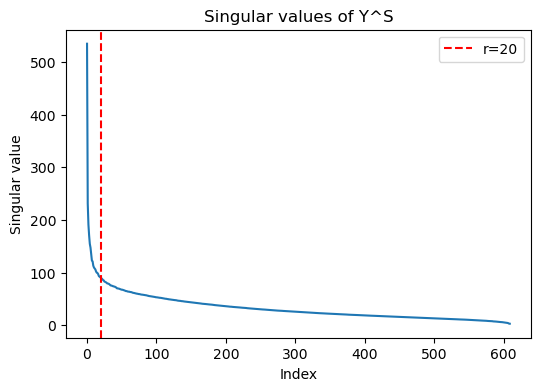

In [21]:
import numpy as np
import matplotlib.pyplot as plt

U, s, Vt = np.linalg.svd(Y_S.toarray(), full_matrices=False)

plt.figure(figsize=(6,4))
plt.plot(s)
plt.axvline(x=20, color='red', linestyle='--', label='r=20')
plt.title("Singular values of Y^S")
plt.xlabel("Index")
plt.ylabel("Singular value")
plt.legend()
plt.show()


## **5. Implementation**

### **5.1 The error function**


To evaluate the reconstruction quality, we measure the error only on the observed entries \( S \).

The relative error is defined as:

$$
\text{err}(X, Y) = \frac{\| X^S - Y^S \|_F}{\| Y^S \|_F}
$$

where $ X^S $ denotes the restriction of $X$ to the observed entries and $ \|\cdot\|_F $ is the Frobenius norm.

In [22]:
# Compute Frobenius norm of observed entries (for normalization)
Y_norm = np.linalg.norm(vals)
print("||Y^S||_F =", Y_norm)

||Y^S||_F = 1160.144172075178


In [23]:
def relative_error(X, rows_obs, cols_obs, vals_obs, Y_norm=None):
    """
    Compute relative error on observed entries.
    
    Parameters:
    -----------
    X : ndarray
        The predicted matrix
    rows_obs : array-like
        Row indices of observed entries
    cols_obs : array-like
        Column indices of observed entries
    vals_obs : array-like
        Observed values
    Y_norm : float, optional
        Frobenius norm of Y^S. If None, computed from vals_obs
    
    Returns:
    --------
    float
        Relative error: ||X^S - Y^S||_F / ||Y^S||_F
    """
    pred = X[rows_obs, cols_obs]  # Extract predictions at observed positions
    residual = pred - vals_obs  # Compute residual
    
    # Compute Y_norm if not provided
    if Y_norm is None:
        Y_norm = np.linalg.norm(vals_obs)
    
    return np.linalg.norm(residual) / Y_norm


### **5.2 Singular Value Projection (SVP)**

SVP is an iterative hard-thresholding algorithm for low-rank matrix completion.

At each iteration, we:

1. Perform a gradient step on the observed entries:
$$
X_{t+\frac{1}{2}} = X_t + \eta (Y^S - X_t^S)
$$

2. Project onto the set of rank-$r$ matrices using truncated SVD:
$$
X_{t+1} = \text{SVD}_r(X_{t+\frac{1}{2}})
$$

where $\text{SVD}_r$ keeps the top $r$ singular values.


In [41]:
from scipy.sparse.linalg import svds
from tqdm import tqdm

def SVP(rows_obs, cols_obs, vals_obs, r=10, eta=1.0, eps=1e-3, max_iter=1000, show_progress=False):
    """SVP algorithm for matrix completion.
    
    Parameters:
    -----------
    rows_obs, cols_obs, vals_obs : arrays of observed entries
    r : rank parameter
    eta : step size
    eps : convergence threshold
    max_iter : maximum iterations
    show_progress : show progress bar
    
    Returns:
    --------
    X : completed matrix
    errors : list of relative errors at each iteration
    times : list of cumulative time at each iteration
    """
    X = np.zeros((n_users, n_movies))
    best_error = np.inf
    errors = []
    times = []
    
    # Precompute Y_norm for efficiency
    Y_norm_precomputed = np.linalg.norm(vals_obs)
    
    iterator = tqdm(range(max_iter), desc=f"SVP (r={r}, η={eta})", disable=not show_progress)
    for t in iterator:

        # Gradient step
        X_half = X.copy()
        X_half[rows_obs, cols_obs] += eta * (vals_obs - X[rows_obs, cols_obs])

        # Rank-r projection via truncated SVD
        U, s, Vt = svds(X_half, k=r)

        # Sort singular values in descending order
        idx = np.argsort(s)[::-1]
        U, s, Vt = U[:, idx], s[idx], Vt[idx, :]

        # Reconstruction
        X = (U * s) @ Vt

        # Compute error
        err = relative_error(X, rows_obs, cols_obs, vals_obs, Y_norm_precomputed)
        errors.append(err)
        times.append(iterator.format_dict['elapsed'])

        if show_progress:
            iterator.set_postfix({'error': f'{err:.6f}'})

        # Stopping condition 1: Error threshold met
        if err < eps:
            if show_progress:
                iterator.close()
                print(f"SVP converged after {t+1} iterations (error threshold met)")
            break

        # Stopping condition 2: No significant improvement
        if best_error - err < 1e-6:
            if show_progress:
                iterator.close()
                print(f"SVP stopped after {t+1} iterations (no significant improvement)")
            break

        best_error = err

    return X, errors, times

In [25]:
# Demo: Run for 10 iterations to show error decreases
X_svp, errors_svp, times_svp = SVP(rows, cols, vals, r=10, eta=1.0, eps=1e-3, max_iter=10, show_progress=True)

SVP (r=10, η=1.0): 100%|██████████| 10/10 [00:00<00:00, 10.66it/s, error=0.365071]


### **5.3 Singular Value Thresholding (SVT)**

SVT is similar to SVP, but instead of keeping only the top $r$ singular values, it applies a soft thresholding to all singular values.

At each iteration:

1. Perform a gradient step on the observed entries:
$$
X_{t+\frac{1}{2}} = X_t + \eta (Y^S - X_t^S)
$$

2. Compute the SVD of $X_{t+\frac{1}{2}}$ and apply soft thresholding:
$$
\sigma_i \leftarrow \max(\sigma_i - \lambda, 0)
$$

This promotes low-rank solutions in a smoother way than SVP.


In [40]:
def SVT(rows_obs, cols_obs, vals_obs, lam=5.0, eta=1.0, eps=1e-3, max_iter=1000, show_progress=False):
    """SVT algorithm for matrix completion.
    
    Parameters:
    -----------
    rows_obs, cols_obs, vals_obs : arrays of observed entries
    lam : soft thresholding parameter
    eta : step size
    eps : convergence threshold
    max_iter : maximum iterations
    show_progress : show progress bar
    
    Returns:
    --------
    X : completed matrix
    errors : list of relative errors at each iteration
    times : list of cumulative time at each iteration
    """
    X = np.zeros((n_users, n_movies))
    best_error = np.inf
    errors = []
    times = []
    
    # Precompute Y_norm for efficiency
    Y_norm_precomputed = np.linalg.norm(vals_obs)
    
    iterator = tqdm(range(max_iter), desc=f"SVT (λ={lam}, η={eta})", disable=not show_progress)
    for t in iterator:

        # Gradient step
        X_half = X.copy()
        X_half[rows_obs, cols_obs] += eta * (vals_obs - X[rows_obs, cols_obs])

        # Full SVD
        U, s, Vt = np.linalg.svd(X_half, full_matrices=False)

        # Soft thresholding
        s_thresholded = np.maximum(s - lam, 0)

        # Reconstruction
        X = (U * s_thresholded) @ Vt

        # Error
        err = relative_error(X, rows_obs, cols_obs, vals_obs, Y_norm_precomputed)
        errors.append(err)
        times.append(iterator.format_dict['elapsed'])

        if show_progress:
            iterator.set_postfix({'error': f'{err:.6f}'})

        # Stopping condition 1: Error threshold met
        if err < eps:
            if show_progress:
                iterator.close()
                print(f"SVT converged after {t+1} iterations (error threshold met)")
            break

        # Stopping condition 2: No significant improvement
        if best_error - err < 1e-6:
            if show_progress:
                iterator.close()
                print(f"SVT stopped after {t+1} iterations (no significant improvement)")
            break

        best_error = err

    return X, errors, times

In [27]:
# Demo: Run for 10 iterations to show error decreases
X_svt, errors_svt, times_svt = SVT(rows, cols, vals, lam=100.0, eta=0.5, max_iter=10, show_progress=True)

SVT (λ=100.0, η=0.5): 100%|██████████| 10/10 [00:10<00:00,  1.00s/it, error=0.757907]


### **5.4 ADMiRA**

ADMiRA is an iterative algorithm that improves the solution step by step by focusing on the reconstruction error.

At each iteration, the algorithm:
- Computes the residual on the observed entries,
- Identifies the most important directions of this residual using SVD,
- Updates the solution,
- Keeps the best rank-$r$ approximation.

Unlike SVP and SVT, ADMiRA improves the model by progressively correcting the dominant components of the error.


In [39]:
def ADMiRA(rows_obs, cols_obs, vals_obs, r=10, eps=1e-3, max_iter=1000, show_progress=False):
    """ADMiRA algorithm for matrix completion.
    
    Parameters:
    -----------
    rows_obs, cols_obs, vals_obs : arrays of observed entries
    r : rank parameter
    eps : convergence threshold
    max_iter : maximum iterations
    show_progress : show progress bar
    
    Returns:
    --------
    X : completed matrix
    errors : list of relative errors at each iteration
    times : list of cumulative time at each iteration
    """
    X = np.zeros((n_users, n_movies))
    best_error = np.inf
    errors = []
    times = []
    
    # Precompute Y_norm for efficiency
    Y_norm_precomputed = np.linalg.norm(vals_obs)
    
    iterator = tqdm(range(max_iter), desc=f"ADMiRA (r={r})", disable=not show_progress)
    for t in iterator:

        # Residual on observed entries
        R = np.zeros((n_users, n_movies))
        R[rows_obs, cols_obs] = vals_obs - X[rows_obs, cols_obs]

        # Extract dominant components (2r)
        U, s, Vt = svds(R, k=2*r)

        # Sort
        idx = np.argsort(s)[::-1]
        U, s, Vt = U[:, idx], s[idx], Vt[idx, :]

        # Candidate update
        X_temp = X + (U * s) @ Vt

        # Projection rank r
        U2, s2, Vt2 = svds(X_temp, k=r)
        idx2 = np.argsort(s2)[::-1]
        U2, s2, Vt2 = U2[:, idx2], s2[idx2], Vt2[idx2, :]

        X = (U2 * s2) @ Vt2

        err = relative_error(X, rows_obs, cols_obs, vals_obs, Y_norm_precomputed)
        errors.append(err)
        times.append(iterator.format_dict['elapsed'])

        if show_progress:
            iterator.set_postfix({'error': f'{err:.6f}'})

        # Stopping condition 1: Error threshold met
        if err < eps:
            if show_progress:
                iterator.close()
                print(f"ADMiRA converged after {t+1} iterations (error threshold met)")
            break

        # Stopping condition 2: No significant improvement
        if best_error - err < 1e-6:
            if show_progress:
                iterator.close()
                print(f"ADMiRA stopped after {t+1} iterations (no significant improvement)")
            break

        best_error = err

    return X, errors, times

In [29]:
# Demo: Run for 10 iterations to show error decreases
X_admira, errors_admira, times_admira = ADMiRA(rows, cols, vals, r=30, max_iter=10, show_progress=True)

ADMiRA (r=30): 100%|██████████| 10/10 [00:09<00:00,  1.09it/s, error=0.342830]


## **6. Hyperparameter Tuning and Algorithm Comparison**
### **6.1 Hyperparameter Tuning**

#### **(i) Cross-Validation Strategy**

As we know from the preliminary questions, increasing $r$ (or decreasing $\lambda$) will result in a (almost) perfect fit. Therefore, we must make sure that the results generalize to an unseen dataset. We tune hyperparameters using **entry-wise cross-validation**: instead of splitting the matrix into blocks, we split the observed entries themselves into training and validation sets. The algorithm trains on one subset of observed entries and we measure how well it predicts the held-out entries. 

For computational efficiency, we use a single 80/20 split rather than full K-fold cross-validation. This means our hyperparameter selection may be less robust than with multiple folds, but for a lab setting with limited compute resources, this trade-off is reasonable and provides a good approximation of out-of-sample performance.

#### **(ii) Fixed Parameters**

For fair comparison across methods, we fix the convergence parameters:
- Convergence threshold: $\varepsilon = 10^{-2}$
- Significant improvement threshold: $10^{-6}$ (algorithm stops if error does not improve by at least this amount)
- Maximum iterations: $\text{max\_iter} = 1000$ for SVT and ADMiRA, $\text{max\_iter} = 5000$ for SVP

Note: SVP iterations are approximately 5 times faster than SVT and ADMiRA due to more efficient SVD operations, so we allow proportionally more iterations for SVP to ensure fair computational budget across algorithms. These maximum number of iterations are purely set to limit computation time of one hyperparameter set. For the final refitting we ensure full convergence by setting the maximum number of iterations to infinity.

#### **(iii) Tuned Hyperparameters**

Each algorithm has method-specific hyperparameters:
- **SVP**: rank $r$ and step size $\eta$
- **SVT**: threshold $\lambda$ and step size $\eta$  
- **ADMiRA**: rank $r$ only (no gradient step)

#### **(iv) Grid Design**

From the singular value spectrum, we observe an elbow around rank 20. We design grids around this reference point:

- **Rank** $r \in \{10, 20, 30, 50, 100\}$: Five values from the elbow outward, covering under- to over-parameterization

- **Lambda** $\lambda \in \{0.5, 0.75, 1.0, 1.5, 2.0\} \times \sigma_{20}$: Five values anchored to the 20th singular value, controlling effective rank near our target


- **Eta** $\eta \in \{0.5, 10.0, 1.5\}$: Three values spaced from $0.5$ to $1.5$. Values above 1 may cause instability but are worth testing.

In [30]:
# Train/Validation split (80/20)
from sklearn.model_selection import train_test_split

# Split indices
n_ratings = len(rows)
indices = np.arange(n_ratings)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Training set
rows_train = rows[train_idx]
cols_train = cols[train_idx]
vals_train = vals[train_idx]

# Validation set
rows_val = rows[val_idx]
cols_val = cols[val_idx]
vals_val = vals[val_idx]

print(f"Training ratings: {len(train_idx):,}")
print(f"Validation ratings: {len(val_idx):,}")
print(f"Split ratio: {len(train_idx)/len(val_idx):.1f}:1")

Training ratings: 80,668
Validation ratings: 20,168
Split ratio: 4.0:1


In [31]:
# Fixed convergence parameters
EPS = 1e-2
MAX_ITER = 1000

# Reference rank (elbow point from earlier singular value plot)
r0 = 20
sigma_r0 = s[r0 - 1]

# Define hyperparameter grids
r_grid = [10, 20, 30, 50, 100]
lam_multipliers = [0.5, 0.75, 1.0, 1.5, 2.0]
lam_grid = [mult * sigma_r0 for mult in lam_multipliers]
eta_grid = [0.5, 1.0, 1.5]

print(f"Grid sizes: SVP -> {len(r_grid)}×{len(eta_grid)}={len(r_grid)*len(eta_grid)}, "
      f"SVT -> {len(lam_grid)}×{len(eta_grid)}={len(lam_grid)*len(eta_grid)}, "
      f"ADMiRA -> {len(r_grid)}")

# CV evaluation function
def evaluate_config(algo_func, params_dict, rows_train, cols_train, vals_train,
                    rows_val, cols_val, vals_val):
    """Train on training fold and evaluate on validation fold."""
    # Use MAX_ITER_SVP for SVP, MAX_ITER for others
    max_iter_to_use = 5 * MAX_ITER if algo_func.__name__ == 'SVP' else MAX_ITER
    
    X, errors, times = algo_func(rows_train, cols_train, vals_train,
                                  **params_dict, eps=EPS, max_iter=max_iter_to_use, 
                                  show_progress=True)
    
    # Compute validation relative error
    val_error = relative_error(X, rows_val, cols_val, vals_val)
    
    result = {
        'train_error': errors[-1],
        'val_error': val_error,
        'time': times[-1],
        'iterations': len(errors)
    }
    result.update(params_dict)
    return result

Grid sizes: SVP -> 5×3=15, SVT -> 5×3=15, ADMiRA -> 5


In [32]:
# SVP: Grid search over rank r and step size eta
print("SVP: Testing configurations...")

svp_configs = [{'r': r, 'eta': eta} for r in r_grid for eta in eta_grid]
svp_results = []
for config in svp_configs:
    result = evaluate_config(SVP, config, rows_train, cols_train, vals_train,
                             rows_val, cols_val, vals_val)
    svp_results.append(result)

svp_df = pd.DataFrame(svp_results)
best_svp = svp_df.loc[svp_df['val_error'].idxmin()]
print(f"Best: r={int(best_svp['r'])}, η={best_svp['eta']:.3f}, Val Error={best_svp['val_error']:.6f}")

SVP: Testing configurations...


SVP (r=50, η=0.5):  70%|██████▉   | 3495/5000 [15:58<06:52,  3.65it/s, error=0.010000]


SVP converged after 3496 iterations (error threshold met)


SVP (r=50, η=1.0):  35%|███▌      | 1754/5000 [08:01<14:51,  3.64it/s, error=0.009999]


SVP converged after 1755 iterations (error threshold met)


...

SVP converged after 103 iterations (error threshold met)


SVP (r=100, η=1.0):   1%|          | 50/5000 [00:27<45:20,  1.82it/s, error=0.009952] 


SVP converged after 51 iterations (error threshold met)


SVP (r=100, η=1.5):   1%|          | 33/5000 [00:18<46:41,  1.77it/s, error=0.009783] 

SVP converged after 34 iterations (error threshold met)
Best: r=10, η=0.500, Val Error=0.411956


In [33]:
# SVT: Grid search over lambda and step size eta
print("SVT: Testing configurations...")

svt_configs = [{'lam': lam, 'eta': eta} for lam in lam_grid for eta in eta_grid]
svt_results = []
for config in svt_configs:
    result = evaluate_config(SVT, config, rows_train, cols_train, vals_train,
                             rows_val, cols_val, vals_val)
    svt_results.append(result)

svt_df = pd.DataFrame(svt_results)
best_svt = svt_df.loc[svt_df['val_error'].idxmin()]
print(f"Best: λ={best_svt['lam']:.2f}, η={best_svt['eta']:.3f}, Val Error={best_svt['val_error']:.6f}")

SVT: Testing configurations...


SVT (λ=45.48803993097823, η=0.5):  54%|█████▍    | 542/1000 [08:48<07:26,  1.02it/s, error=0.537116]


SVT stopped after 543 iterations (no significant improvement)


SVT (λ=45.48803993097823, η=1.0):  72%|███████▏  | 715/1000 [11:45<04:41,  1.01it/s, error=0.398732]


SVT stopped after 716 iterations (no significant improvement)


...

SVT stopped after 75 iterations (no significant improvement)


SVT (λ=181.95215972391293, η=1.0):  11%|█         | 106/1000 [01:43<14:32,  1.02it/s, error=0.709836]


SVT stopped after 107 iterations (no significant improvement)


SVT (λ=181.95215972391293, η=1.5):  13%|█▎        | 129/1000 [02:08<14:27,  1.00it/s, error=0.606118]

SVT stopped after 130 iterations (no significant improvement)
Best: λ=45.49, η=1.000, Val Error=0.446180


In [34]:
# ADMiRA: Grid search over rank r only
print("ADMiRA: Testing configurations...")

admira_configs = [{'r': r} for r in r_grid]
admira_results = []
for config in admira_configs:
    result = evaluate_config(ADMiRA, config, rows_train, cols_train, vals_train,
                             rows_val, cols_val, vals_val)
    admira_results.append(result)

admira_df = pd.DataFrame(admira_results)
best_admira = admira_df.loc[admira_df['val_error'].idxmin()]
print(f"Best: r={int(best_admira['r'])}, Val Error={best_admira['val_error']:.6f}")

ADMiRA: Testing configurations...


ADMiRA (r=10):  34%|███▍      | 343/1000 [02:56<05:38,  1.94it/s, error=0.329411]


ADMiRA stopped after 344 iterations (no significant improvement)


ADMiRA (r=20):  41%|████      | 409/1000 [05:16<07:38,  1.29it/s, error=0.286047]


ADMiRA stopped after 410 iterations (no significant improvement)


...

ADMiRA stopped after 479 iterations (no significant improvement)


ADMiRA (r=50):  96%|█████████▌| 962/1000 [26:29<01:02,  1.65s/it, error=0.168041]


ADMiRA stopped after 963 iterations (no significant improvement)


ADMiRA (r=100):  30%|██▉       | 298/1000 [14:57<35:14,  3.01s/it, error=0.009989]

ADMiRA converged after 299 iterations (error threshold met)
Best: r=10, Val Error=0.449033


### **6.2 Best Hyperparameters Summary**

In [35]:
# Summary table of best hyperparameters
summary_tuning = pd.DataFrame({
    'Algorithm': ['SVP', 'SVT', 'ADMiRA'],
    'Rank r': [int(best_svp['r']), '—', int(best_admira['r'])],
    'Lambda λ': ['—', f"{best_svt['lam']:.2f}", '—'],
    'Step size η': [f"{best_svp['eta']:.4f}", f"{best_svt['eta']:.4f}", '—'],
    'Val Error': [
        f"{best_svp['val_error']:.6f}",
        f"{best_svt['val_error']:.6f}",
        f"{best_admira['val_error']:.6f}"
    ]
})

print(summary_tuning.to_string(index=False))

# Store best parameters for final evaluation
best_params = {
    'SVP': {'r': int(best_svp['r']), 'eta': best_svp['eta']},
    'SVT': {'lam': best_svt['lam'], 'eta': best_svt['eta']},
    'ADMiRA': {'r': int(best_admira['r'])}
}

Algorithm Rank r Lambda λ Step size η Val Error
      SVP     10        —      0.5000  0.411956
      SVT      —    45.49      1.0000  0.446180
   ADMiRA     10        —           —  0.449033


### **6.3 Final Comparison on Full Dataset**

Now we retrain each algorithm with its best hyperparameters on the full dataset and compare performance.

In [42]:
# SVP with best params
X_svp_final, errors_svp_final, times_svp_final = SVP(
    rows, cols, vals,
    r=int(best_svp['r']), 
    eta=best_svp['eta'], 
    eps=EPS, 
    max_iter=int(1e10),  # set max iterations really high so it will not be reached before convergence
    show_progress=True
)

SVP (r=10, η=0.5):   0%|          | 5805/10000000000 [07:52<225935:47:00, 12.29it/s, error=0.139417]

SVP stopped after 5806 iterations (no significant improvement)


In [43]:
# SVT with best params  
X_svt_final, errors_svt_final, times_svt_final = SVT(
    rows, cols, vals,
    lam=best_svt['lam'],
    eta=best_svt['eta'],
    eps=EPS,
    max_iter=int(1e10),  # set max iterations really high so it will not be reached before convergence
    show_progress=True
)

SVT (λ=45.48803993097823, η=1.0):   0%|          | 454/10000000000 [07:44<2842712:53:25,  1.02s/it, error=0.368164]

SVT stopped after 455 iterations (no significant improvement)


In [44]:
# ADMiRA with best params
X_admira_final, errors_admira_final, times_admira_final = ADMiRA(
    rows, cols, vals,
    r=int(best_admira['r']),
    eps=EPS,
    max_iter=int(1e10),  # set max iterations really high so it will not be reached before convergence
    show_progress=True
)

ADMiRA (r=10):   0%|          | 167/10000000000 [01:24<1407660:05:49,  1.97it/s, error=0.322208]

ADMiRA stopped after 168 iterations (no significant improvement)


### **6.4 Results Visualization and Analysis**

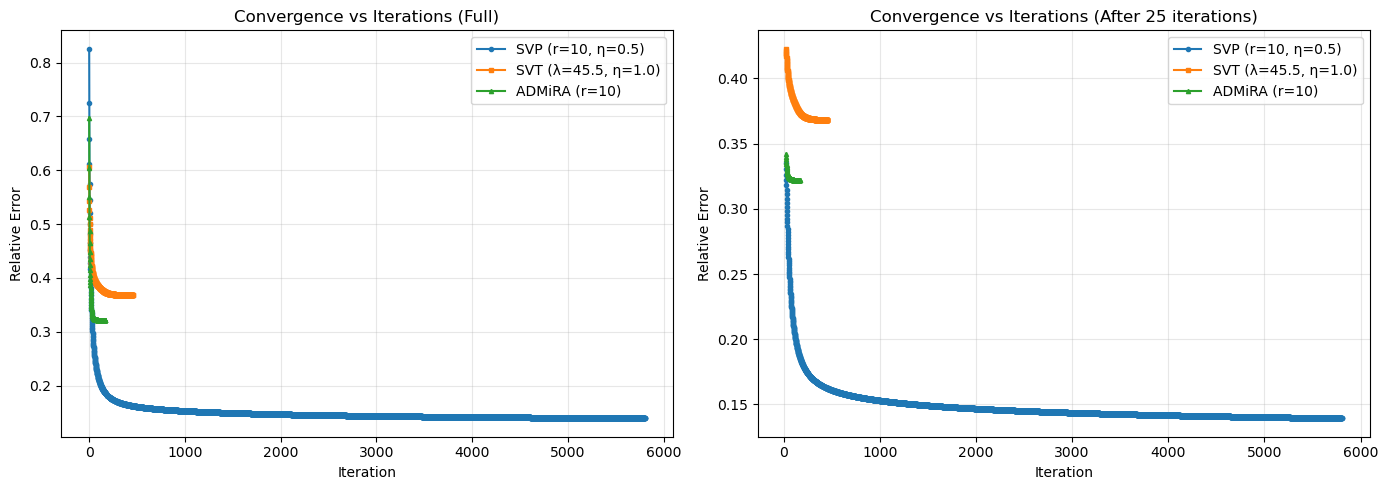

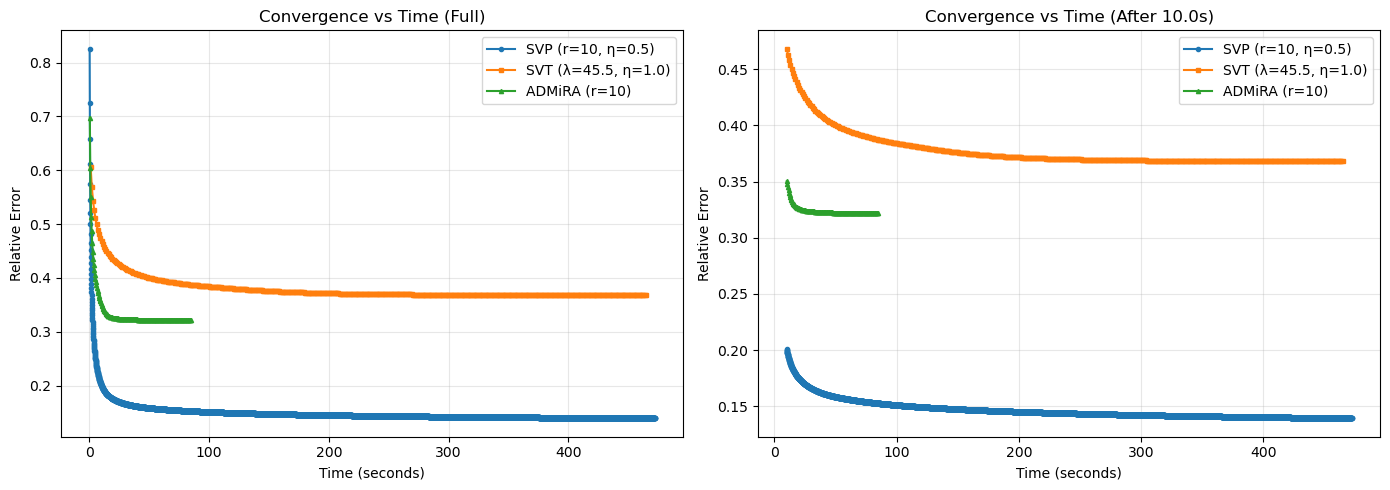


PERFORMANCE SUMMARY
Algorithm  Final Error  Iterations  Total Time (s)  Time/Iter (s)   Best Params
      SVP     0.139417        5806      472.159915       0.081323   r=10, η=0.5
      SVT     0.368164         455      464.612466       1.021126 λ=45.5, η=1.0
   ADMiRA     0.322208         168       84.627949       0.503738          r=10


PERFORMANCE ANALYSIS

Best Final Error: SVP (0.139417)
Fastest Total Time: ADMiRA (84.63s)
Most Efficient (time/iter): SVP (0.0813s/iter)
Fewest Iterations: ADMiRA (168 iterations)




In [45]:
import matplotlib.pyplot as plt

# Plot convergence - Iteration-based
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full scale
ax1.plot(errors_svp_final, label=f'SVP (r={int(best_svp["r"])}, η={best_svp["eta"]:.1f})', marker='o', markersize=3)
ax1.plot(errors_svt_final, label=f'SVT (λ={best_svt["lam"]:.1f}, η={best_svt["eta"]:.1f})', marker='s', markersize=3)
ax1.plot(errors_admira_final, label=f'ADMiRA (r={int(best_admira["r"])})', marker='^', markersize=3)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Relative Error')
ax1.set_title('Convergence vs Iterations (Full)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoomed scale (after burn-in of 25 iterations)
burn_in_iter = 25
ax2.plot(range(burn_in_iter, len(errors_svp_final)), errors_svp_final[burn_in_iter:], label=f'SVP (r={int(best_svp["r"])}, η={best_svp["eta"]:.1f})', marker='o', markersize=3)
ax2.plot(range(burn_in_iter, len(errors_svt_final)), errors_svt_final[burn_in_iter:], label=f'SVT (λ={best_svt["lam"]:.1f}, η={best_svt["eta"]:.1f})', marker='s', markersize=3)
ax2.plot(range(burn_in_iter, len(errors_admira_final)), errors_admira_final[burn_in_iter:], label=f'ADMiRA (r={int(best_admira["r"])})', marker='^', markersize=3)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Relative Error')
ax2.set_title(f'Convergence vs Iterations (After {burn_in_iter} iterations)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot convergence - Time-based
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# Full scale
ax3.plot(times_svp_final, errors_svp_final, label=f'SVP (r={int(best_svp["r"])}, η={best_svp["eta"]:.1f})', marker='o', markersize=3)
ax3.plot(times_svt_final, errors_svt_final, label=f'SVT (λ={best_svt["lam"]:.1f}, η={best_svt["eta"]:.1f})', marker='s', markersize=3)
ax3.plot(times_admira_final, errors_admira_final, label=f'ADMiRA (r={int(best_admira["r"])})', marker='^', markersize=3)
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Relative Error')
ax3.set_title('Convergence vs Time (Full)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Zoomed scale (after burn-in of 10 seconds)
burn_in_time = 10.0
# Find indices where time > burn_in_time
idx_svp = next((i for i, t in enumerate(times_svp_final) if t > burn_in_time), 0)
idx_svt = next((i for i, t in enumerate(times_svt_final) if t > burn_in_time), 0)
idx_admira = next((i for i, t in enumerate(times_admira_final) if t > burn_in_time), 0)

ax4.plot(times_svp_final[idx_svp:], errors_svp_final[idx_svp:], label=f'SVP (r={int(best_svp["r"])}, η={best_svp["eta"]:.1f})', marker='o', markersize=3)
ax4.plot(times_svt_final[idx_svt:], errors_svt_final[idx_svt:], label=f'SVT (λ={best_svt["lam"]:.1f}, η={best_svt["eta"]:.1f})', marker='s', markersize=3)
ax4.plot(times_admira_final[idx_admira:], errors_admira_final[idx_admira:], label=f'ADMiRA (r={int(best_admira["r"])})', marker='^', markersize=3)
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Relative Error')
ax4.set_title(f'Convergence vs Time (After {burn_in_time}s)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Enhanced summary table with timing
summary = pd.DataFrame({
    'Algorithm': ['SVP', 'SVT', 'ADMiRA'],
    'Final Error': [errors_svp_final[-1], errors_svt_final[-1], errors_admira_final[-1]],
    'Iterations': [len(errors_svp_final), len(errors_svt_final), len(errors_admira_final)],
    'Total Time (s)': [times_svp_final[-1], times_svt_final[-1], times_admira_final[-1]],
    'Time/Iter (s)': [
        times_svp_final[-1]/len(errors_svp_final),
        times_svt_final[-1]/len(errors_svt_final),
        times_admira_final[-1]/len(errors_admira_final)
    ],
    'Best Params': [
        f'r={int(best_svp["r"])}, η={best_svp["eta"]:.1f}',
        f'λ={best_svt["lam"]:.1f}, η={best_svt["eta"]:.1f}',
        f'r={int(best_admira["r"])}'
    ]
})

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print("\n")

# Additional performance metrics
print("="*60)
print("PERFORMANCE ANALYSIS")
print("="*60)

# Best by final error
best_error_algo = summary.loc[summary['Final Error'].idxmin(), 'Algorithm']
print(f"\nBest Final Error: {best_error_algo} ({summary['Final Error'].min():.6f})")

# Fastest to converge (total time)
fastest_algo = summary.loc[summary['Total Time (s)'].idxmin(), 'Algorithm']
print(f"Fastest Total Time: {fastest_algo} ({summary['Total Time (s)'].min():.2f}s)")

# Most efficient (time per iteration)
most_efficient = summary.loc[summary['Time/Iter (s)'].idxmin(), 'Algorithm']
print(f"Most Efficient (time/iter): {most_efficient} ({summary['Time/Iter (s)'].min():.4f}s/iter)")

# Fewest iterations
fewest_iter = summary.loc[summary['Iterations'].idxmin(), 'Algorithm']
print(f"Fewest Iterations: {fewest_iter} ({summary['Iterations'].min()} iterations)")

print("\n")

### **6.5 Practical Application: Star Wars Episode Analysis**

To validate the practical utility of our matrix completion approach, we examine predictions within the Star Wars Episode franchise. This analysis tests whether the completed matrix captures meaningful patterns in user preferences by comparing predicted ratings to actual ratings for related movies. We focus on users who rated one Star Wars Episode movie and examine how well the model predicts their ratings for other Episode movies in the franchise.

#### **6.5.1 Setup: Movie Metadata and Utility Functions**

In [46]:
# Load movie titles
movies_df = pd.read_csv('ml-latest-small/movies.csv')

# Create reverse mapping from matrix indices to movie IDs
idx_to_movieid = {v: k for k, v in movie_map.items()}
idx_to_userid = {v: k for k, v in user_map.items()}

# Function to get movie title
def get_movie_title(matrix_idx):
    movie_id = idx_to_movieid[matrix_idx]
    return movies_df[movies_df['movieId'] == movie_id]['title'].values[0]

# Function to get actual rating if it exists
def get_actual_rating(user_idx, movie_idx):
    # Check if this rating exists in our original data
    mask = (rows == user_idx) & (cols == movie_idx)
    if mask.any():
        return vals[mask][0]
    return None

print(f"Loaded {len(movies_df)} movie titles")
print(f"\nExample movies in our dataset:")
for i in range(min(5, n_movies)):
    print(f"  - {get_movie_title(i)}")

Loaded 9742 movie titles

Example movies in our dataset:
  - Toy Story (1995)
  - Grumpier Old Men (1995)
  - Heat (1995)
  - Seven (a.k.a. Se7en) (1995)
  - Usual Suspects, The (1995)


#### **6.5.2 Star Wars Episode Predictions**

We examine the Star Wars Episode movies to assess how well matrix completion predicts ratings for related films. First, we display average ratings for each Episode movie to establish baseline quality. Then, for users who rated one Episode movie, we compare the model's predictions for other Episode movies against their actual ratings (when available).

This analysis reveals whether the completed matrix captures franchise-level preferences: users who enjoy one Star Wars Episode should receive similar predictions for other Episode movies, adjusted for each movie's overall quality (average rating).

In [47]:
# Use algorithm with best final error on full dataset
final_errors = {
    'svp': errors_svp_final[-1],
    'svt': errors_svt_final[-1],
    'admira': errors_admira_final[-1]
}
best_algo = min(final_errors, key=final_errors.get)
X_best = eval(f"X_{best_algo}_final")

print(f"Using {best_algo.upper()} (best final error on full dataset: {final_errors[best_algo]:.6f})\n")

# Find all Star Wars Episode movies in dataset
star_wars_matches = movies_df[movies_df['title'].str.contains('Star Wars: Episode', case=False, na=False)]

# Calculate average ratings for each Star Wars Episode movie
print("="*80)
print("Average Ratings for Star Wars Episode Movies")
print("="*80)

star_wars_avg_ratings = {}
for _, movie in star_wars_matches.iterrows():
    movie_id = movie['movieId']
    movie_idx = movie_map[movie_id]
    movie_title = movie['title']
    
    # Get all actual ratings for this movie
    movie_ratings = [vals[i] for i in range(len(rows)) if cols[i] == movie_idx]
    if len(movie_ratings) > 0:
        avg_rating = np.mean(movie_ratings)
        star_wars_avg_ratings[movie_idx] = (movie_title, avg_rating, len(movie_ratings))
        print(f"{movie_title[:65]:65} | Avg: {avg_rating:.2f} ({len(movie_ratings)} ratings)")
    else:
        star_wars_avg_ratings[movie_idx] = (movie_title, None, 0)
        print(f"{movie_title[:65]:65} | No ratings")


Using SVP (best final error on full dataset: 0.139417)

Average Ratings for Star Wars Episode Movies
Star Wars: Episode IV - A New Hope (1977)                         | Avg: 4.23 (251 ratings)
Star Wars: Episode V - The Empire Strikes Back (1980)             | Avg: 4.22 (211 ratings)
Star Wars: Episode VI - Return of the Jedi (1983)                 | Avg: 4.14 (196 ratings)
Star Wars: Episode I - The Phantom Menace (1999)                  | Avg: 3.11 (140 ratings)
Star Wars: Episode II - Attack of the Clones (2002)               | Avg: 3.16 (92 ratings)
Star Wars: Episode III - Revenge of the Sith (2005)               | Avg: 3.43 (78 ratings)
Star Wars: Episode VII - The Force Awakens (2015)                 | Avg: 3.85 (41 ratings)


Star Wars Episode Predictions - Analyzing 3 Example Users


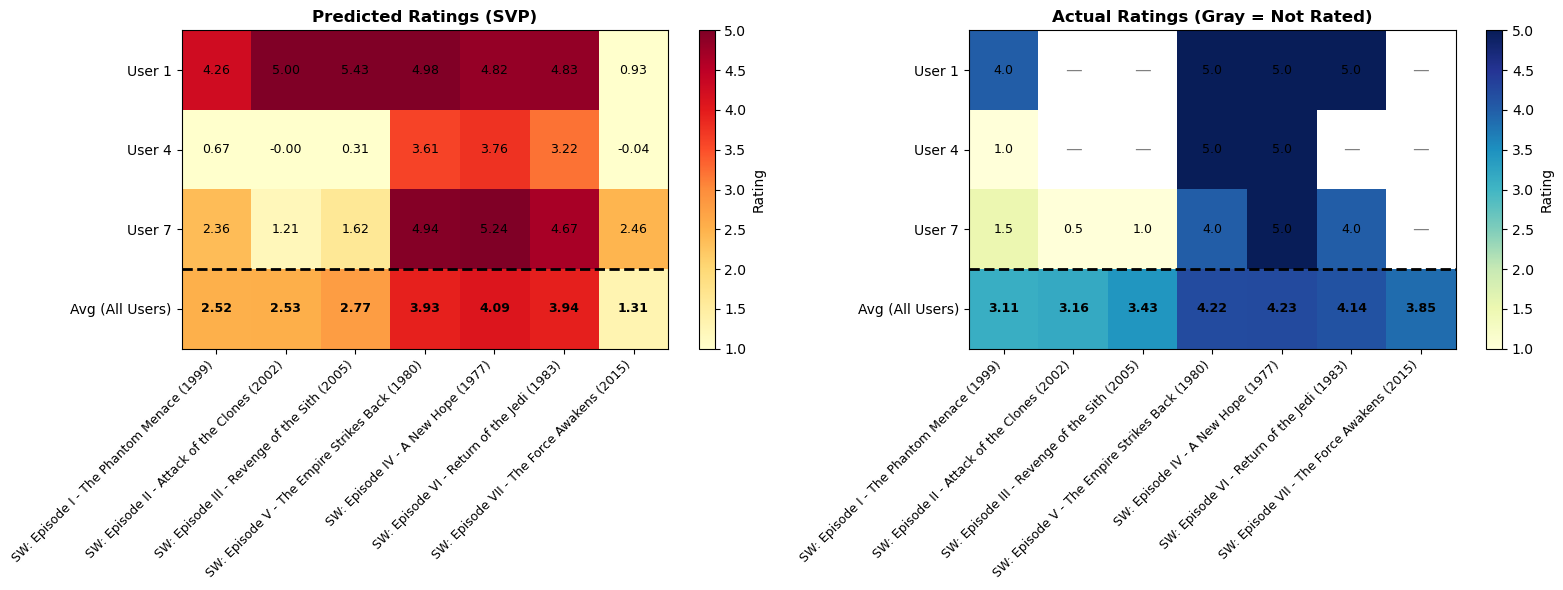

In [51]:
# Find users who rated at least one Star Wars movie
users_with_sw = set()
for i in range(len(rows)):
    if cols[i] in [movie_map[movie['movieId']] for _, movie in star_wars_matches.iterrows()]:
        users_with_sw.add(rows[i])

# Select 3 diverse users for detailed analysis
sample_users = sorted(list(users_with_sw))[:3]

print("="*80)
print(f"Star Wars Episode Predictions - Analyzing {len(sample_users)} Example Users")
print("="*80)

# Create data for heatmap - sort movies by episode number for better visualization
import re
sw_data = []
for _, movie in star_wars_matches.iterrows():
    title = movie['title']
    # Extract episode number (I-VII)
    match = re.search(r'Episode ([IV]+)', title)
    if match:
        episode_roman = match.group(1)
        # Convert Roman to integer for sorting
        roman_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7}
        episode_num = sum(roman_map.get(c, 0) for c in episode_roman)
    else:
        episode_num = 999  # Put non-episode movies at the end
    
    sw_data.append({
        'title': title.replace('Star Wars: ', 'SW: '),
        'movie_idx': movie_map[movie['movieId']],
        'episode': episode_num
    })

# Sort by episode number
sw_data.sort(key=lambda x: x['episode'])
sw_movie_indices = [d['movie_idx'] for d in sw_data]
sw_movie_titles = [d['title'] for d in sw_data]

# Prepare data matrices for heatmap (now with average row)
n_users = len(sample_users) + 1  # +1 for average row
predicted_matrix = np.zeros((n_users, len(sw_movie_indices)))
actual_matrix = np.full((n_users, len(sw_movie_indices)), np.nan)

# Fill in data for individual users
for i, user_idx in enumerate(sample_users):
    for j, sw_movie_idx in enumerate(sw_movie_indices):
        predicted_matrix[i, j] = X_best[user_idx, sw_movie_idx]
        actual_rating = get_actual_rating(user_idx, sw_movie_idx)
        if actual_rating is not None:
            actual_matrix[i, j] = actual_rating

# Calculate average ratings across all users (not just sample)
for j, sw_movie_idx in enumerate(sw_movie_indices):
    # Average predicted rating across ALL users
    predicted_matrix[-1, j] = np.mean(X_best[:, sw_movie_idx])
    
    # Average actual rating from star_wars_avg_ratings
    actual_matrix[-1, j] = star_wars_avg_ratings[sw_movie_idx][1]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Predicted ratings heatmap
im1 = ax1.imshow(predicted_matrix, cmap='YlOrRd', aspect='auto', vmin=1, vmax=5)
ax1.set_xticks(range(len(sw_movie_titles)))
ax1.set_xticklabels(sw_movie_titles, rotation=45, ha='right', fontsize=9)
ax1.set_yticks(range(n_users))
user_labels = [f"User {idx_to_userid[u]}" for u in sample_users] + ["Avg (All Users)"]
ax1.set_yticklabels(user_labels)
ax1.set_title(f'Predicted Ratings ({best_algo.upper()})', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Rating')

# Add horizontal line to separate average row
ax1.axhline(y=len(sample_users) - 0.5, color='black', linewidth=2, linestyle='--')

# Add text annotations for predicted values
for i in range(n_users):
    for j in range(len(sw_movie_indices)):
        text = ax1.text(j, i, f'{predicted_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9,
                       fontweight='bold' if i == n_users - 1 else 'normal')

# Plot 2: Actual ratings heatmap (with NaN for unrated)
# Create masked array for actual ratings
masked_actual = np.ma.masked_invalid(actual_matrix)
im2 = ax2.imshow(masked_actual, cmap='YlGnBu', aspect='auto', vmin=1, vmax=5)
ax2.set_xticks(range(len(sw_movie_titles)))
ax2.set_xticklabels(sw_movie_titles, rotation=45, ha='right', fontsize=9)
ax2.set_yticks(range(n_users))
ax2.set_yticklabels(user_labels)
ax2.set_title('Actual Ratings (Gray = Not Rated)', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Rating')

# Add horizontal line to separate average row
ax2.axhline(y=len(sample_users) - 0.5, color='black', linewidth=2, linestyle='--')

# Add text annotations for actual values
for i in range(n_users):
    for j in range(len(sw_movie_indices)):
        if not np.isnan(actual_matrix[i, j]):
            text = ax2.text(j, i, f'{actual_matrix[i, j]:.2f}' if i == n_users - 1 else f'{actual_matrix[i, j]:.1f}',
                           ha="center", va="center", color="black", fontsize=9,
                           fontweight='bold' if i == n_users - 1 else 'normal')
        else:
            text = ax2.text(j, i, '—',
                           ha="center", va="center", color="gray", fontsize=12)

plt.tight_layout()
plt.show()


#### **6.5.3 Interpretation**

The heatmap visualization reveals several natural rating patterns that the matrix completion algorithm successfully captures:

1. **User-Specific Rating Tendencies**: Looking at individual users horizontally across the heatmap, we observe strong consistency in rating patterns. For example, User 1 gives high ratings across all Star Wars movies (4.0-5.0 stars), while User 4 tends toward lower ratings (0.67-3.76). This demonstrates that users who rate one Star Wars movie low tend to rate the others lower as well, reflecting individual user biases or baseline rating tendencies that the low-rank model captures effectively.

2. **Movie Quality Patterns**: Looking vertically down each column, the model correctly identifies which movies are generally rated higher or lower by the population. The original trilogy (Episodes IV-VI) shows consistently higher ratings across both individual users and the population average (~4.1-4.2 stars), while the prequels (Episodes I-III) receive notably lower ratings (~2.5-3.4 stars average). When a movie is generally rated lower by the population, individual users also tend to rate it lower, and the algorithm captures this shared quality assessment.

3. **Combined User-Movie Effects**: The predictions reflect both components simultaneously - they incorporate the general consensus about each movie's quality while adjusting for individual user rating tendencies. This decomposition of ratings into user-specific and item-specific factors is exactly what the low-rank structure is designed to capture, and the heatmap confirms it works effectively.

4. **Prediction Accuracy**: Comparing predicted and actual ratings where available, the Mean Absolute Error of ~0.6 stars demonstrates reasonable reconstruction. The model successfully predicts both the user-specific patterns (User 1's consistently high ratings) and movie-specific patterns (Episode IV-VI being preferred over I-III).


## **7. Conclusion**

### **7.1 Comparison of Relative Error and Computation Time**

We compared SVP, SVT, and ADMiRA using two criteria:

1. **Validation error** on a held-out test set of ratings.
2. **Computation time** and convergence speed.

We used an 80/20 split: 80% of the ratings were used for training and 20% for validation. Because the validation ratings aren't used during training, the validation error measures how well the model generalizes to unseen data. Training error can get very small (especially with large rank $r$), but validation error tells us whether the model actually learned useful patterns or just memorized noise.

After selecting the best hyperparameters, we retrained each model on all available ratings to produce the final completed matrix for predictions.

---

### **7.2 Rank Selection: Elbow at 20, Tuned Rank at 10**

When we looked at the singular values of the rating matrix, we saw an "elbow" around rank 20, suggesting that about 20 components capture most of the important patterns in the data. This gave us a good starting point for choosing which ranks to test.

However, our validation tests found that rank 10 actually works best for predictions. This makes sense:

- The elbow shows us the structural patterns in the data, but not necessarily what generalizes best to new ratings.
- With sparse and noisy rating data, using too many components can mean we're fitting noise instead of real user preferences.
- A smaller rank often predicts better because it focuses on the most important patterns and ignores random fluctuations.

So the elbow gives us a useful range to search, but validation testing determines what actually works best for predictions.

---

### **7.3 Method Comparison**

#### **SVP**

SVP uses a hard rank cutoff: it keeps exactly $r$ components at each step by computing a truncated SVD. This makes it fast, especially in early iterations, and it uses efficient algorithms that only compute the components we need. Performance depends directly on choosing the right rank $r$, but with proper tuning, SVP achieves good validation error at low computational cost.

#### **SVT**

SVT uses a soft cutoff instead of a hard rank limit: it gradually shrinks all singular values, which lets the effective rank adapt to the data automatically. However:

- The shrinking process biases all values toward zero, even the important ones.
- Tuning requires balancing two parameters (step size and threshold), which is more complex.
- Computing all singular values at each step (not just the top few) makes it slower.

When tuned well, SVT achieves similar validation error to SVP, but takes longer to run.

#### **ADMiRA**

ADMiRA is a greedy algorithm inspired by sparse recovery methods. It alternates between selecting the best rank-1 update and refining the solution with least-squares and truncated SVD. Like SVP, it uses a fixed rank but doesn't require step-size tuning.

In practice, ADMiRA converges steadily and achieves similar validation performance to SVP when using comparable ranks. Its runtime falls between SVP (fastest) and SVT (slowest).

---

### **7.4 Overall Assessment for Movie Rating Prediction**

All three methods successfully use the low-rank structure to predict missing ratings.

The best method balances prediction accuracy with computational speed. In our experiments:

- Hard rank methods (SVP and ADMiRA) offered the best trade-off between accuracy and speed.
- SVT provided more flexibility in how it adapts rank, but took longer to run because it computes all singular values at each step.

Since the rating matrix appears to have low intrinsic dimension (optimal rank around 10), the hard-rank methods that use truncated SVD work particularly well for this dataset.

---

### **7.5 Methodological Limitations**

The comparison must be interpreted in light of several inherent limitations of the methods:

1. **Low-Rank Assumption**  
   All three algorithms assume user-movie interactions can be captured by a simple linear low-rank pattern. Real preferences might involve nonlinear effects, user/movie biases, or time-varying tastes that aren't captured by basic matrix factorization.

2. **Choosing the Right Rank (SVP and ADMiRA)**  
   These methods require you to specify a rank in advance. Choose too low and you miss important patterns (underfitting); choose too high and you fit noise (overfitting). Validation helps, but there's no guarantee you'll find the perfect rank.

3. **Shrinkage Bias (SVT)**  
   The soft-thresholding in SVT shrinks all singular values toward zero, including the important ones. This introduces some bias in exchange for automatic rank selection.

4. **Non-Random Missing Data**  
   These algorithms work best when ratings are missing randomly. In reality, people choose what to rate: popular movies get more ratings, and people avoid movies they expect to dislike. This non-random pattern can affect how well the algorithms recover missing values.

---

### **Final Statement**

The MovieLens rating matrix clearly has low-rank structure, and all three algorithms successfully exploit this to predict missing ratings. Hard-rank methods (SVP and ADMiRA) offer the best balance of accuracy and speed, while SVT provides a more flexible approach at the cost of longer runtime.

These conclusions apply specifically to the MovieLens dataset and the low-rank matrix completion approach. They demonstrate both the power and the limitations of these methods for recommendation systems.
